**Przetwarzanie strumieni danych lista 1 Oliwia Borkowska**

**Zad. 1** Korzystając z jednej z dostępnych bibliotek (np. OpenCV) przygotuj kod w języku Python, który załaduje a następnie zapisze wybrany obraz z/na dysku

Obraz został zapisany na C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat.jpg


(-0.5, 3071.5, 2047.5, -0.5)

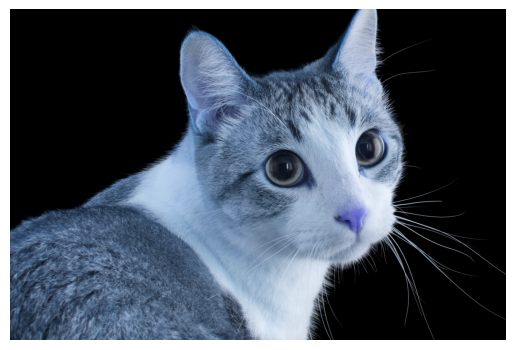

In [63]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

obraz_url = "https://i.natgeofe.com/n/548467d8-c5f1-4551-9f58-6817a8d2c45e/NationalGeographic_2572187_3x2.jpg"
ścieżka = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat.jpg"
obraz = cv2.imread(ścieżka)

odpowiedz = requests.get(obraz_url , stream=True)
if odpowiedz.status_code == 200:
    obraz_array = np.asarray(bytearray(odpowiedz.content), dtype=np.uint8)
    obraz = cv2.imdecode(obraz_array, cv2.IMREAD_COLOR)

    if obraz is None:
        print("Nie udało się wczytać obrazu.")
    else:
        cv2.imwrite(ścieżka, obraz)
        print(f"Obraz został zapisany na {ścieżka}")
else:
    print("Nie udało się pobrać obrazu. Sprawdź ponownie URL.")
    
fig= plt.figure()
plt.imshow(obraz)
plt.axis("off")

    

**Zad. 2** Przygotuj w języku Python kod, który wygeneruje histogram dla załadowanego obrazu z zadania 1.

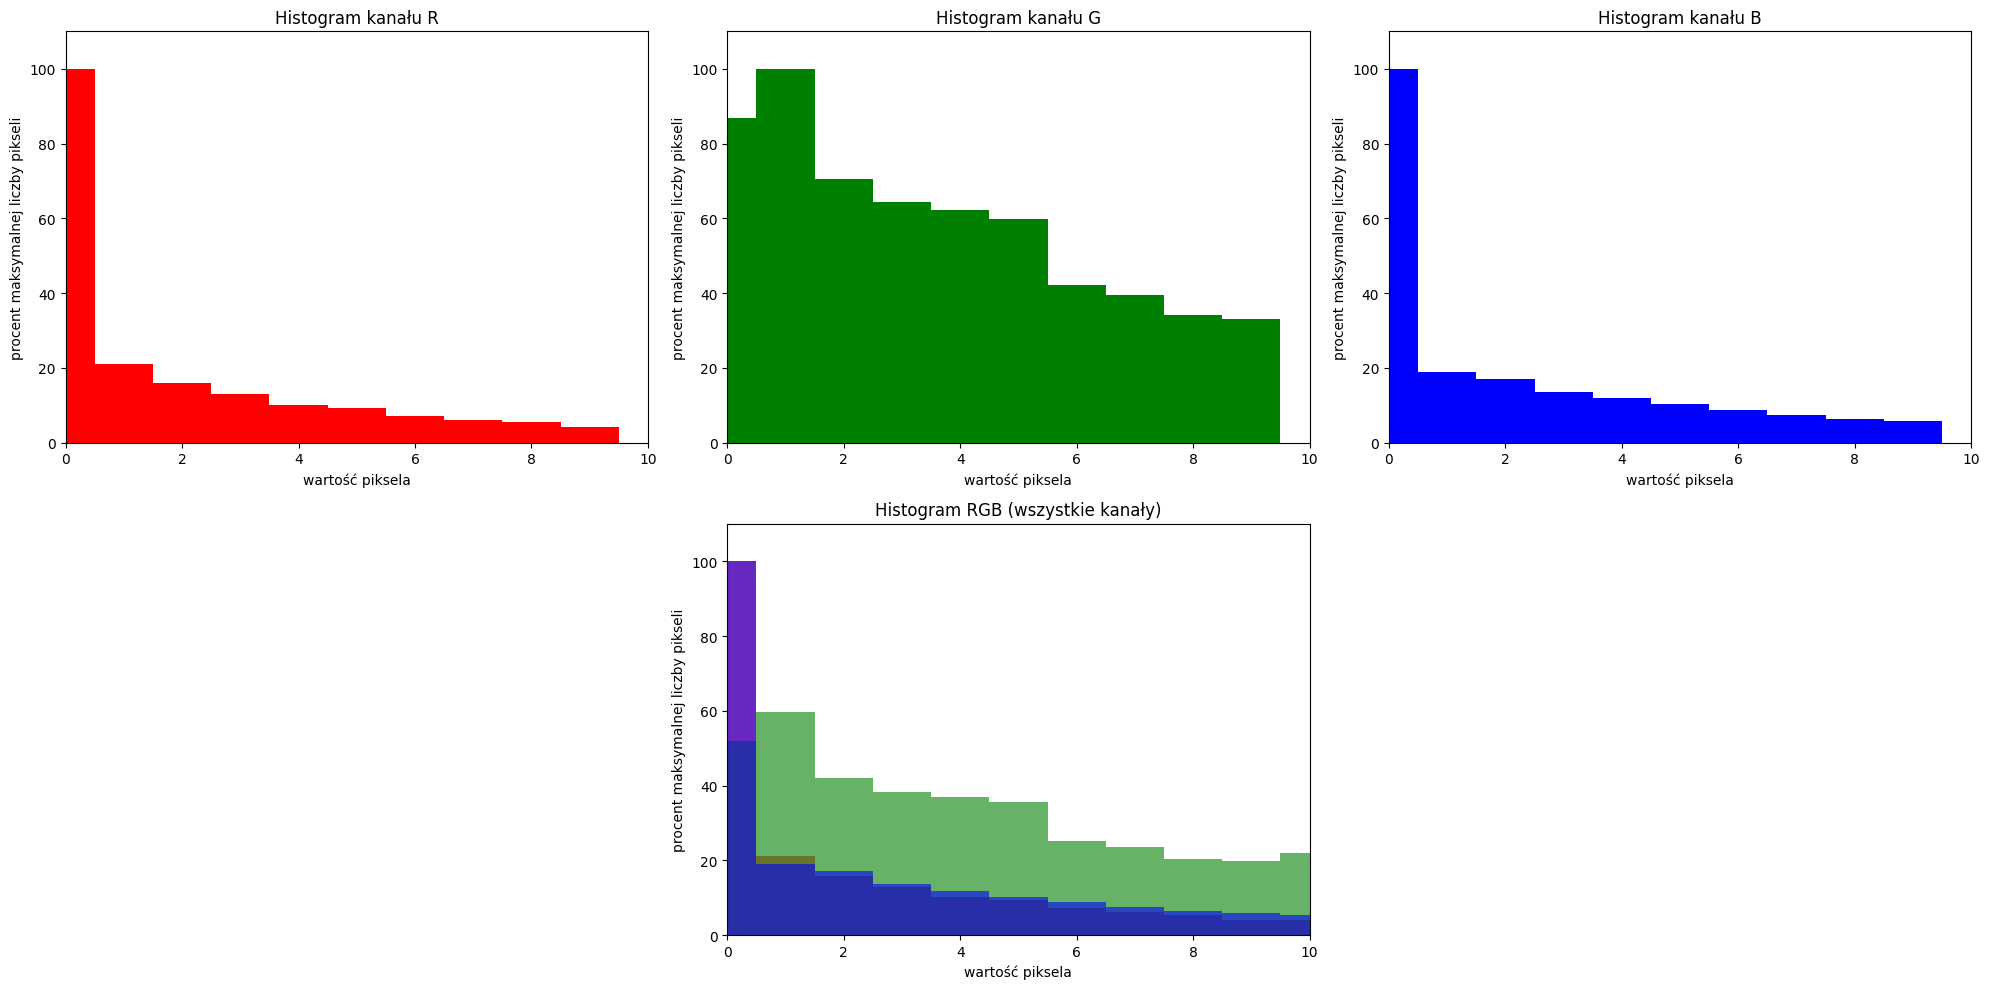

In [65]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# wczytanie innego - bardziej kolorowego obrazu
ścieżka = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/parrot.jpg"
obraz = cv2.imread(ścieżka)

# Sprawdzenie poprawności wczytania
if obraz is None:
    print("Nie udało się wczytać obrazu. Sprawdź ponownie ścieżkę.")
else:
    # przejście z BGR do RGB)
    obraz = cv2.cvtColor(obraz, cv2.COLOR_BGR2RGB)
                        
    kanały = ('R', 'G', 'B')
    kolory = ('red', 'green', 'blue')

    fig, axs = plt.subplots(2, 3, figsize=(20, 10), gridspec_kw={'height_ratios': [1, 1]})

    maks_wartość = 0

    for i, (kolor, kanał) in enumerate(zip(kolory, kanały)):
        hist = cv2.calcHist([obraz], [i], None, [10], [0, 10])

        hist = hist / hist.max() * 100   # normalizacja
        maks_wartość = max(maks_wartość, max(hist))  # szukamy najwyższej wartości
        

        axs[0, i].bar(range(10), hist.ravel(), color=kolor, width=1)
        axs[0, i].set_xlim([0, 10])
        axs[0, i].set_ylim([0, 110])  # Skala do 110% dla lepszej widoczności
        axs[0, i].set_title(f'Histogram kanału {kanał}')
        axs[0, i].set_xlabel("wartość piksela")
        axs[0, i].set_ylabel("procent maksymalnej liczby pikseli")


    axs[1, 1].set_title("Histogram RGB (wszystkie kanały)")
    for i, kolor in enumerate(kolory):
        hist = cv2.calcHist([obraz], [i], None, [256], [0, 256])
        hist = hist / hist.max() * 100  # normalizacja
        axs[1, 1].bar(range(256), hist.ravel(), color=kolor, width=1, alpha=0.6)
    
    axs[1, 1].set_xlim([0, 10])
    axs[1, 1].set_ylim([0, 110])
    axs[1, 1].set_xlabel("wartość piksela")
    axs[1, 1].set_ylabel("procent maksymalnej liczby pikseli")

    axs[1, 0].axis('off')
    axs[1, 2].axis('off')

    plt.tight_layout()
    plt.show()


**Zad 3.** Przygotuj w języku Python kod, który wygeneruje i zwizualizuje szum „sól i pieprz”.  

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

ścieżka = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat.jpg"
obraz = cv2.imread(ścieżka, cv2.IMREAD_GRAYSCALE)  # zmiana na szary kolor

if obraz is None:
    raise ValueError("Nie udało się wczytać obrazu. Sprawdź ponownie ścieżkę.")

def sol_i_pieprz(image, salt_prob=0.2, pepper_prob=0.2):
    noisy_image = image.copy()
    total_pixels = image.size

    # sól  - białe piksele (wartość 255)
    num_salt = int(total_pixels * salt_prob)
    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255

    # pieprz - czarne piksele (wartość 0)
    num_pepper = int(total_pixels * pepper_prob)
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0

    return noisy_image

def obraz_z_szumem(salt, pepper):
    noisy_image = sol_i_pieprz(obraz, salt, pepper)
    
    # wyświetlenie obrazów obok siebie
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(obraz, cmap="gray")
    axes[0].set_title("Oryginalny obraz kota")
    axes[0].axis("off") # wyłączenie osi

    axes[1].imshow(noisy_image, cmap="gray")
    axes[1].set_title("Obraz kota z szumem 'sól i pieprz'")
    axes[1].axis("off")

plt.show()

# dodanie funckji suwaka
suwak_sol = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.02, description="Sól")
suwak_pieprz = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.02, description="Pieprz")

# wywołanie suwaka
widgets.interactive(obraz_z_szumem, salt=suwak_sol, pepper=suwak_pieprz)


interactive(children=(FloatSlider(value=0.02, description='Sól', max=1.0, step=0.05), FloatSlider(value=0.02, …

**Zad. 4** Przygotuj w języku Python kod, który obróci załadowany w zadaniu 1 obraz o 90 stopni

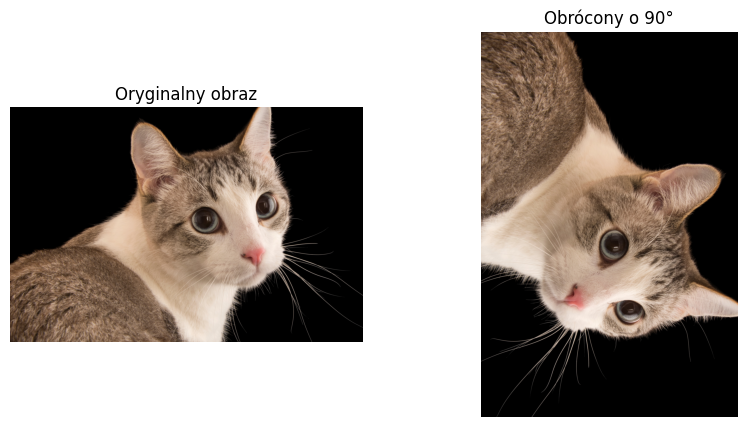

Obrócony obraz zapisano jako: C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat_rotated.jpg


In [48]:
import cv2
import matplotlib.pyplot as plt


ścieżka = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat.jpg"
obraz = cv2.imread(ścieżka)

if obraz is None:
    print("Nie udało się wczytać obrazu. Sprawdź ponownie ścieżkę.")
else:
    obrócony_obraz = cv2.rotate(obraz, cv2.ROTATE_90_CLOCKWISE)

    obraz_rgb = cv2.cvtColor(obraz, cv2.COLOR_BGR2RGB)
    obrócony_rgb = cv2.cvtColor(obrócony_obraz, cv2.COLOR_BGR2RGB)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(obraz_rgb)
    axs[0].set_title("Oryginalny obraz")
    axs[0].axis("off")

    axs[1].imshow(obrócony_rgb)
    axs[1].set_title("Obrócony o 90°")
    axs[1].axis("off")

    plt.show()

    # zapis obróconego obrazu
    ścieżka_obróconego = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat_rotated.jpg"
    cv2.imwrite(ścieżka_obróconego, obrócony_obraz)
    print(f"Obrócony obraz zapisano jako: {ścieżka_obróconego}")


**Zad. 5** Przygotuj w języku Python kod, który wygeneruje szum Riciana, Poissona i Rayleigha. Dla każdego z tych szumów przygotuj histogram. W tym celu wykorzystaj odpowiednie biblioteki w języku Python.


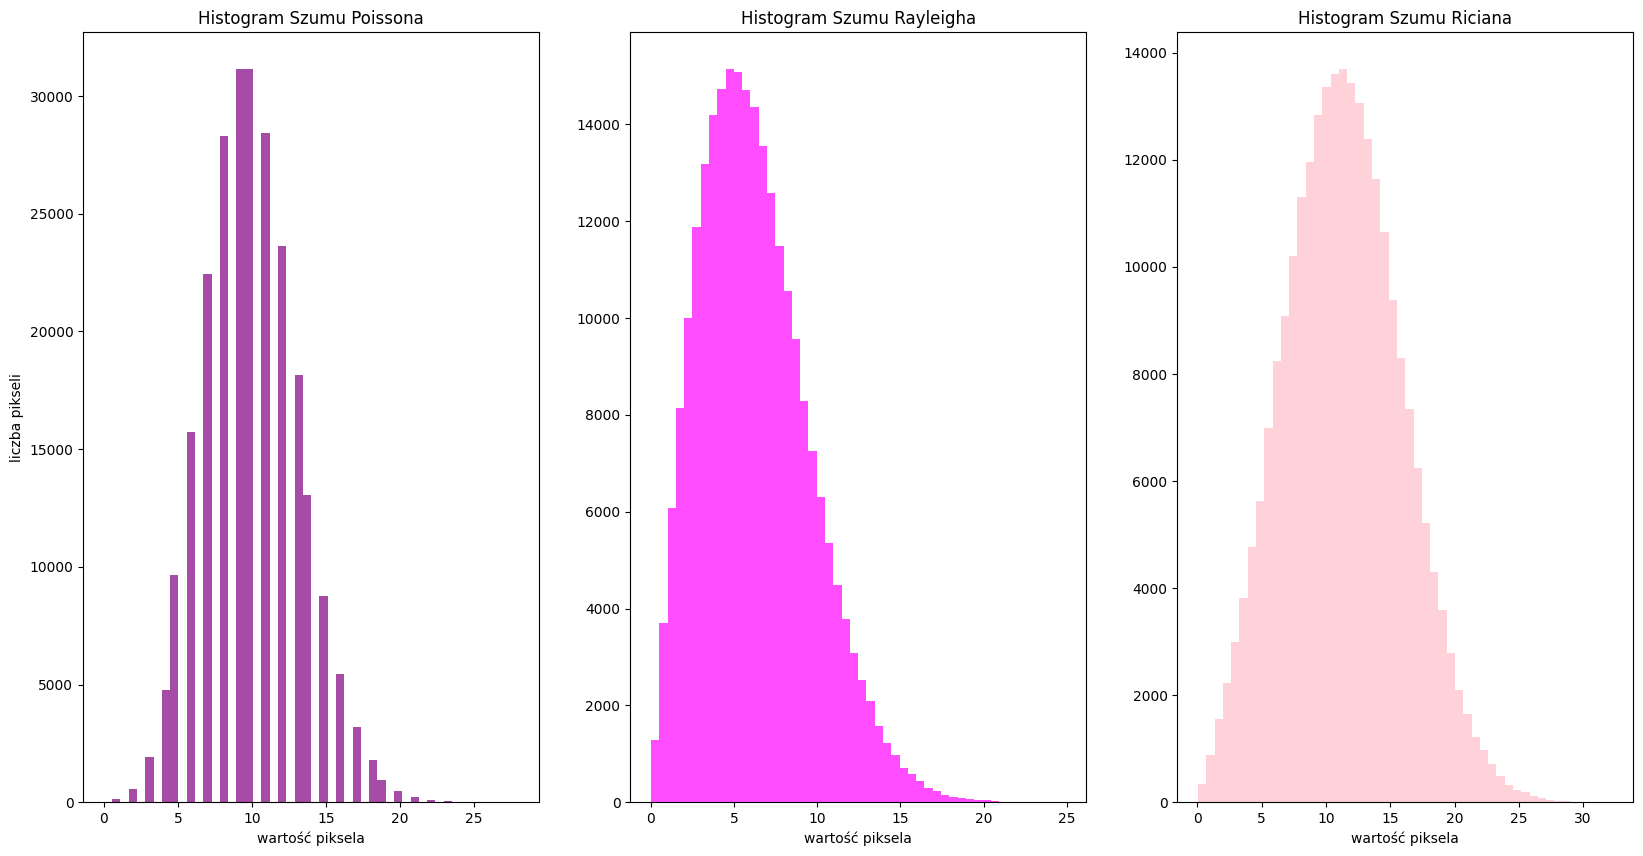

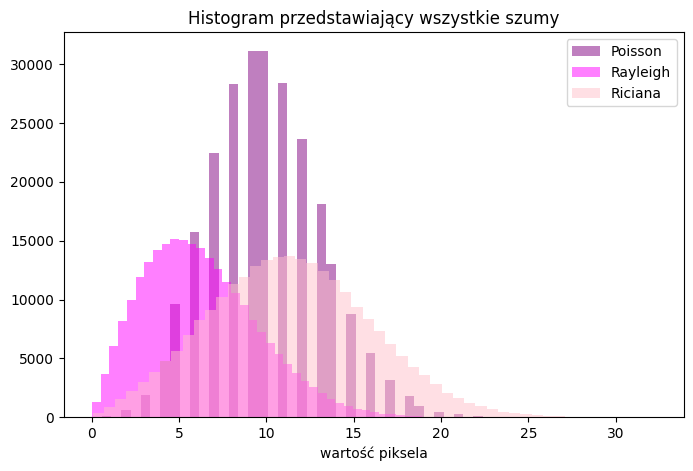

In [58]:
import numpy as np
import matplotlib.pyplot as plt

rozmiar = (500, 500)  # rozmiar macierzy do

# szum Poissona
lambda_poisson = 10
szum_poissona = np.random.poisson(lambda_poisson, rozmiar)

# szum Rayleigha
scale_rayleigh = 5
szum_rayleigha = np.random.rayleigh(scale_rayleigh, rozmiar)

# Szum Riciana

sigma = 5  # odchylenie standardowe
a = 10  # Wartość przesunięcia (deterministyczna składowa sygnału)
X = np.random.normal(a, sigma, rozmiar)
Y = np.random.normal(0, sigma, rozmiar)
szum_riciana = np.sqrt(X**2 + Y**2)

fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# histogram szumu Poissona
axs[0].hist(szum_poissona.flatten(), bins=50, color='purple', alpha=0.7)
axs[0].set_title("Histogram Szumu Poissona")
axs[0].set_xlabel("wartość piksela")
axs[0].set_ylabel("liczba pikseli")

# histogram szumu Rayleigha
axs[1].hist(szum_rayleigha.flatten(), bins=50, color='magenta', alpha=0.7)
axs[1].set_title("Histogram Szumu Rayleigha")
axs[1].set_xlabel("wartość piksela")

# histogram szumu Riciana
axs[2].hist(szum_riciana.flatten(), bins=50, color='pink', alpha=0.7)
axs[2].set_title("Histogram Szumu Riciana")
axs[2].set_xlabel("wartość piksela")

# histogram przedstawiający wszystkie szumy
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(szum_poissona.flatten(), bins=50, color='purple', alpha=0.5, label="Poisson")
ax2.hist(szum_rayleigha.flatten(), bins=50, color='magenta', alpha=0.5, label="Rayleigh")
ax2.hist(szum_riciana.flatten(), bins=50, color='pink', alpha=0.5, label="Riciana")
ax2.set_title("Histogram przedstawiający wszystkie szumy")
ax2.set_xlabel("wartość piksela")
ax2.legend()

plt.show()


to samo zadanie, ale z suwakiem pozwalającym użytkownikowi wybór stopni obrotu

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from scipy.ndimage import rotate


ścieżka = "C:/Users/user/PycharmProjects/pythonProject1premium/Przetwarzanie strumieni danych/cat.jpg"
obraz = cv2.imread(ścieżka)

if obraz is None:
    print("Nie udało się wczytać obrazu.")
else:
    obraz = cv2.cvtColor(obraz, cv2.COLOR_BGR2RGB)


    suwak = widgets.FloatSlider(
        value=0,
        min=0,
        max=360,
        step=1,
        description="Kąt obrotu",
        continuous_update=True
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    wyświetlenie = ax.imshow(obraz)
    ax.axis("off")

    def update_obraz(kąt):
        """ Aktualizuje obraz po zmianie wartości suwaka """
        obrócony = rotate(obraz, angle=kąt, reshape=False)  # Obrót obrazu
        wyświetlenie.set_data(obrócony)  # Aktualizacja obrazu
        ax.set_title(f"Obraz obrócony o {kąt}°")
        fig.canvas.draw_idle()  # Odświeżenie wykresu

# Wyświetlenie suwaka i podpięcie funkcji
display(suwak)
widgets.interactive(update_obraz, kąt=suwak)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy import signal  # zawiera funkcję sinc


def whittaker_shannon_interpolation(f=2.0, fs=20.0):
    # Okres próbkowania
    T = 1/fs
    
    # Generowanie czasu próbkowania
    t = np.arange(0, 1, T)  # 1 sekunda sygnału
    y = np.sin(2 * np.pi * f * t)  # Wartości sygnału w punktach próbkowania
    
    # Sygnał ciągły dla wizualizacji i obliczenia błędu
    t_cont = np.linspace(0, 1, 1000)
    y_cont = np.sin(2 * np.pi * f * t_cont)
    
    # Interpolacja metodą Whittakera-Shannona
    y_interp = np.zeros_like(t_cont)
    
    # Ograniczamy sumę do faktycznych próbek
    for i in range(len(t)):
        # scipy.signal.sinc(x) oblicza sin(πx)/(πx)
        sincArg = (t_cont - t[i]) / T
        y_interp += y[i] * signal.sinc(sincArg)
    
    # Obliczenie błędu interpolacji
    error = y_cont - y_interp
    
    # Tworzenie wykresu
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Wykres sygnału oryginalnego, próbek i interpolacji
    ax1.plot(t_cont, y_cont, 'b-', label='Sygnał ciągły')
    ax1.plot(t_cont, y_interp, 'g-', label='Interpolacja Whittakera-Shannona')
    ax1.stem(t, y, linefmt='r-', markerfmt='ro', basefmt='k-', label='Próbki')
    ax1.set_xlabel('Czas [s]')
    ax1.set_ylabel('Amplituda')
    ax1.set_title(f'Sygnał sinusoidalny (f={f} Hz, fs={fs} Hz) i jego interpolacja')
    ax1.legend()
    ax1.grid(True)
    
    # Wykres błędu interpolacji
    ax2.plot(t_cont, error, 'r-')
    ax2.set_xlabel('Czas [s]')
    ax2.set_ylabel('Błąd')
    ax2.set_title('Błąd interpolacji (różnica między sygnałem ciągłym a interpolowanym)')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Interaktywne suwaki
interact(
    whittaker_shannon_interpolation,
    f=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description='Częstotliwość [Hz]'),
    fs=FloatSlider(value=20.0, min=2.0, max=100.0, step=1.0, description='Częstotliwość próbkowania [Hz]')
)


interactive(children=(FloatSlider(value=2.0, description='Częstotliwość [Hz]', max=10.0, min=0.1), FloatSlider…

<function __main__.whittaker_shannon_interpolation(f=2.0, fs=20.0)>